In [ ]:
!pip install transformers==4.40.0 torch scikit-learn \
             matplotlib seaborn wordcloud kaggle --quiet
print('✅ Done')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 137.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
✅ Done


In [ ]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
else:
    print('⚠️  No GPU — Runtime > Change runtime type > T4 GPU')

✅ Device: cuda
   GPU: Tesla T4


In [ ]:
# The CSV is named 'Combined Data.csv' in this dataset
df = pd.read_csv('Combined Data.csv')

print(f'Shape   : {df.shape}')
print(f'Columns : {df.columns.tolist()}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nClass distribution:\n{df["status"].value_counts()}')
df.head(6)

Shape   : (53043, 3)
Columns : ['Unnamed: 0', 'statement', 'status']

Missing values:
Unnamed: 0      0
statement     362
status          0
dtype: int64

Class distribution:
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
5,5,"every break, you must be nervous, like somethi...",Anxiety


In [ ]:
# Standardise column names regardless of how the CSV came
df.columns = df.columns.str.strip().str.lower()

# Rename to standard names we'll use throughout
# Handles both 'statement/status' and 'text/label' variants
col_map = {}
for col in df.columns:
    if 'state' in col or 'text' in col or 'statement' in col:
        col_map[col] = 'text'
    elif 'status' in col or 'label' in col or 'class' in col:
        col_map[col] = 'label'
df.rename(columns=col_map, inplace=True)

# Drop rows with missing text or label
df.dropna(subset=['text', 'label'], inplace=True)
df['text']  = df['text'].astype(str).str.strip()
df['label'] = df['label'].astype(str).str.strip()

# Drop any rows where text is empty after stripping
df = df[df['text'].str.len() > 0].reset_index(drop=True)

print(f'Shape after cleaning : {df.shape}')
print(f'\nClasses found:\n{df["label"].value_counts()}')

Shape after cleaning : (52681, 3)

Classes found:
label
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


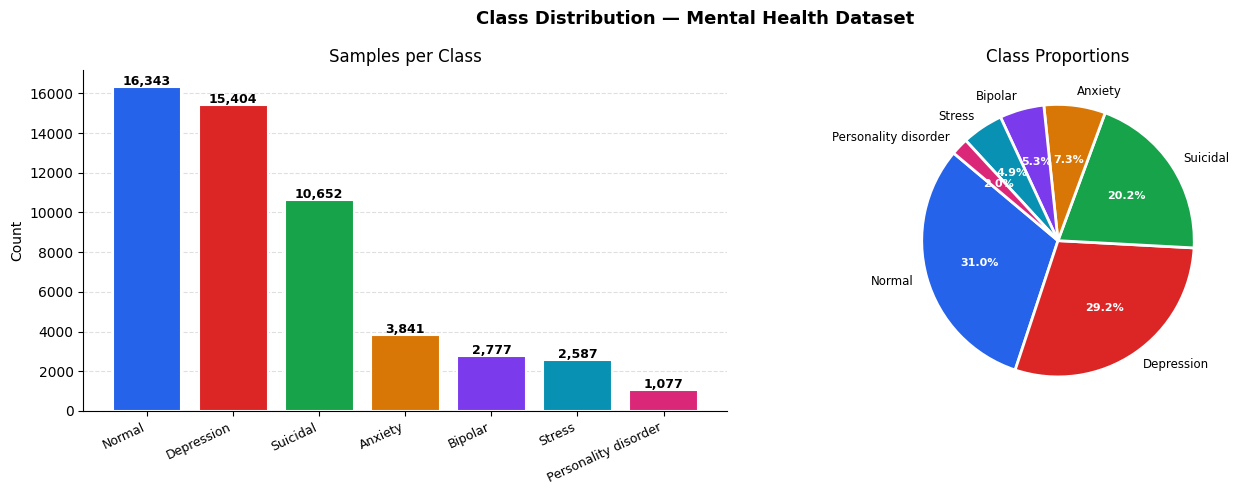

In [ ]:
vc = df['label'].value_counts()

PALETTE = [
    '#2563EB', '#DC2626', '#16A34A', '#D97706',
    '#7C3AED', '#0891B2', '#DB2777'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution — Mental Health Dataset',
             fontsize=13, fontweight='bold')

# Bar chart
bars = axes[0].bar(vc.index, vc.values,
                   color=PALETTE[:len(vc)], edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'{cnt:,}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticklabels(vc.index, rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel('Count'); axes[0].set_title('Samples per Class')
axes[0].spines[['top','right']].set_visible(False)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.4)
axes[0].set_axisbelow(True)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    vc.values, labels=vc.index,
    colors=PALETTE[:len(vc)],
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(linewidth=2, edgecolor='white'),
    textprops={'fontsize': 8.5}
)
for at in autotexts:
    at.set_fontsize(8); at.set_color('white'); at.set_fontweight('bold')
axes[1].set_title('Class Proportions')

plt.tight_layout(); plt.show()

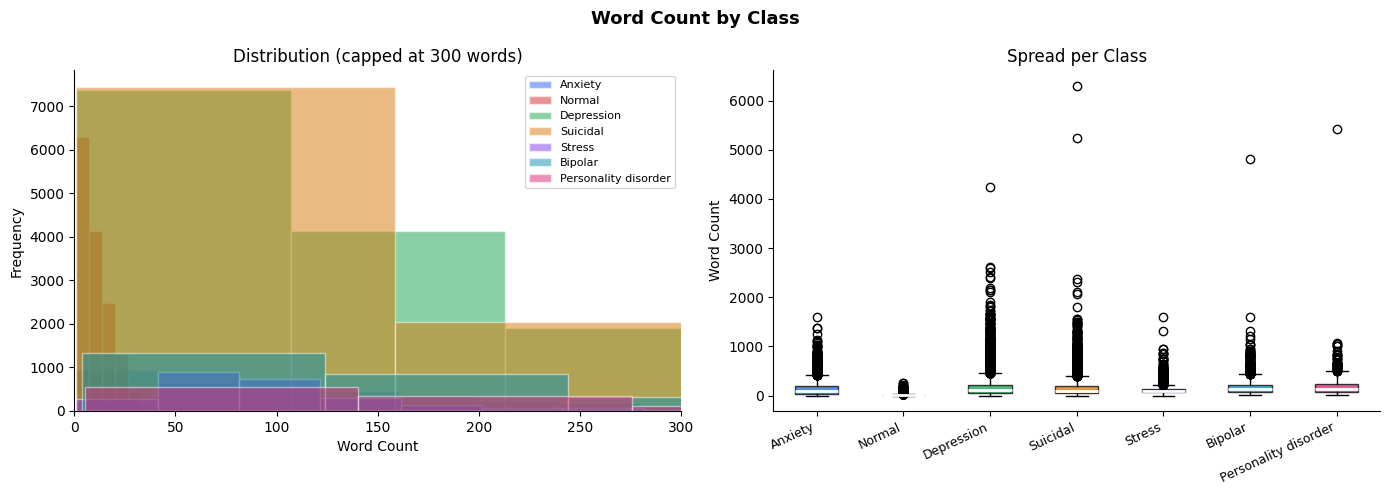

                        count   mean    std  min   25%    50%    75%     max
label                                                                       
Anxiety                3841.0  143.8  152.6  1.0  41.0  102.0  192.0  1592.0
Bipolar                2777.0  176.2  176.5  4.0  74.0  129.0  220.0  4804.0
Depression            15404.0  168.0  188.2  1.0  54.0  113.0  215.0  4239.0
Normal                16343.0   17.2   22.8  1.0   6.0   10.0   18.0   255.0
Personality disorder   1077.0  179.3  221.9  5.0  66.0  137.0  236.0  5419.0
Stress                 2587.0  114.6  105.9  1.0  64.0   87.0  127.0  1606.0
Suicidal              10652.0  146.4  187.0  1.0  42.0   92.0  186.0  6300.0


In [ ]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Word Count by Class', fontsize=13, fontweight='bold')

classes = df['label'].unique()

# Overlapping histogram
for i, cls in enumerate(classes):
    subset = df[df['label'] == cls]['word_count']
    axes[0].hist(subset, bins=40, alpha=0.5,
                color=PALETTE[i % len(PALETTE)], label=cls, edgecolor='white')
axes[0].set_xlabel('Word Count'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution (capped at 300 words)')
axes[0].set_xlim(0, 300)
axes[0].legend(fontsize=8)
axes[0].spines[['top','right']].set_visible(False)

# Boxplot per class
data_per_class = [df[df['label'] == cls]['word_count'].values for cls in classes]
bp = axes[1].boxplot(data_per_class, labels=classes, patch_artist=True,
                      medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1].set_xticklabels(classes, rotation=25, ha='right', fontsize=9)
axes[1].set_ylabel('Word Count'); axes[1].set_title('Spread per Class')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout(); plt.show()

print(df.groupby('label')['word_count'].describe().round(1))

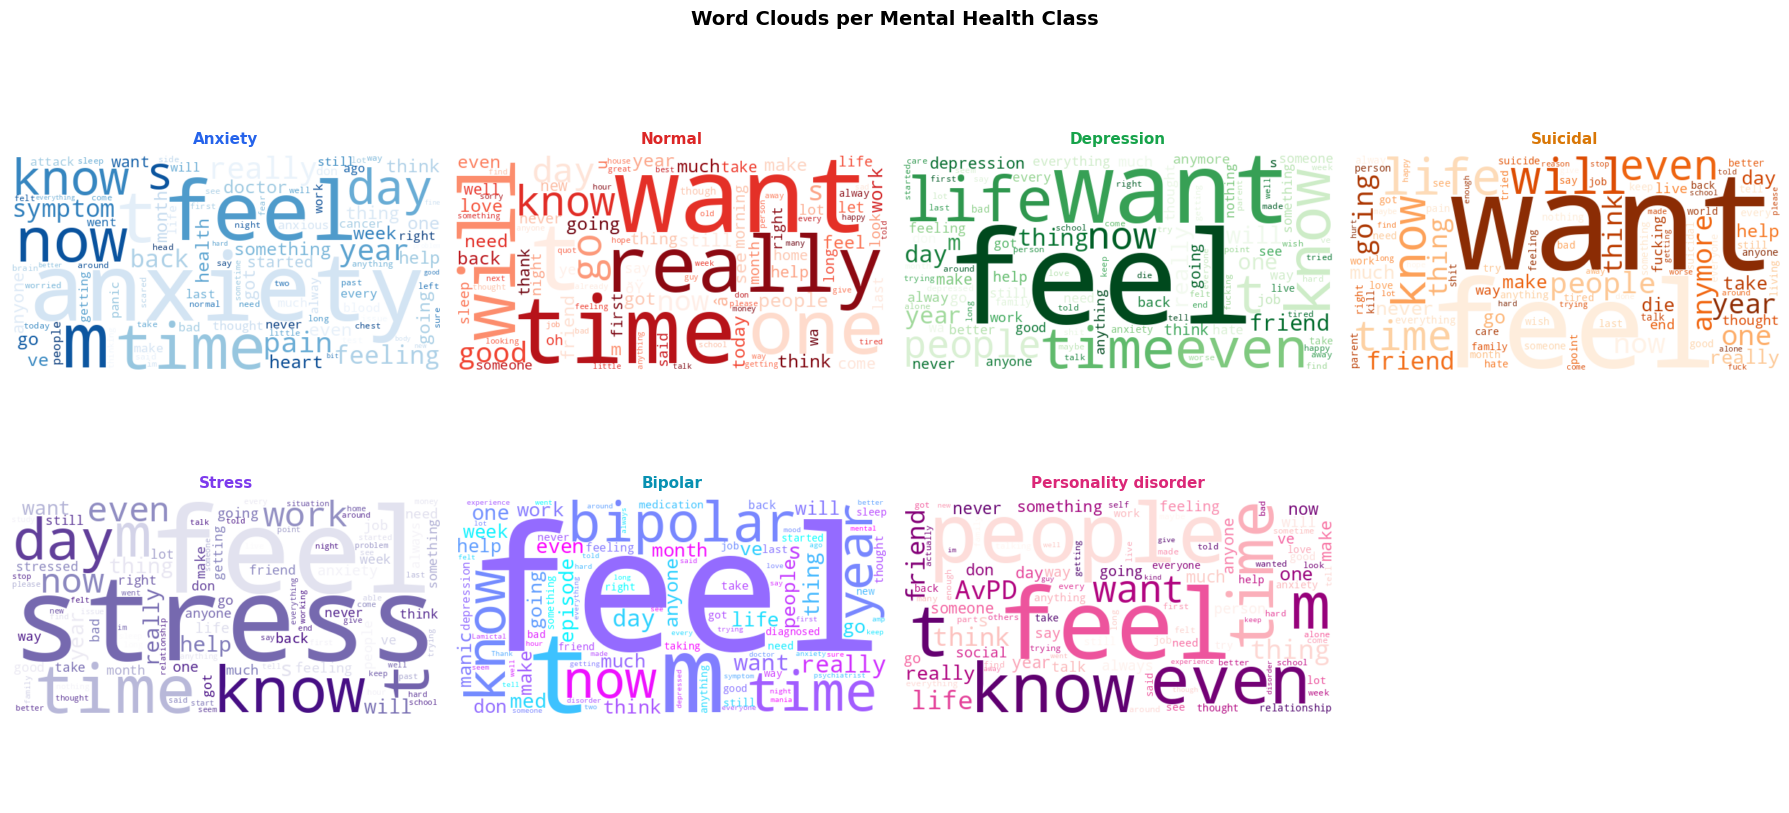

In [ ]:
from wordcloud import WordCloud

classes   = df['label'].unique()
n         = len(classes)
cols      = 4
rows      = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes      = axes.flatten()
fig.suptitle('Word Clouds per Mental Health Class',
             fontsize=14, fontweight='bold', y=1.01)

CMAPS = ['Blues', 'Reds', 'Greens', 'Oranges', 'Purples', 'cool', 'RdPu']

for i, cls in enumerate(classes):
    text = ' '.join(df[df['label'] == cls]['text'].tolist())
    text = re.sub(r'http\S+|www\S+|@\w+', '', text)
    wc = WordCloud(
        width=600, height=300,
        background_color='white',
        colormap=CMAPS[i % len(CMAPS)],
        max_words=100,
        collocations=False
    ).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(cls, fontsize=11, fontweight='bold',
                      color=PALETTE[i % len(PALETTE)], pad=8)

# Hide any unused subplot slots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout(); plt.show()

In [ ]:
import re

def clean_text(text):
    """
    Cleans mental health posts while preserving
    emotionally significant content. We keep negations
    ('not', 'never', 'no') and first-person pronouns
    ('i', 'my', 'myself') — both are strong signals
    in mental health language.
    """
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
    text = re.sub(r'<.*?>', '', text)                 # remove HTML tags
    text = re.sub(r'@\w+', '', text)                   # remove mentions
    text = re.sub(r'#(\w+)', r'\1', text)              # keep hashtag word
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)          # remove non-ASCII
    text = re.sub(r'\s+', ' ', text).strip()            # normalise whitespace
    return text

df['clean_text'] = df['text'].apply(clean_text)

# Sanity check
print('Sample cleaned texts:\n')
for _, row in df[['clean_text', 'label']].sample(5, random_state=42).iterrows():
    print(f'  [{row["label"]:22}]  {row["clean_text"][:80]}')

Sample cleaned texts:

  [Normal                ]  I'm lazy to complain about it ba ihh
  [Normal                ]  i think the wifi on my iphone is broken it will quot connect quot but when i act
  [Bipolar               ]  Good tracking apps? I've been trying to find apps to track not just my overall m
  [Depression            ]  I have recently looked into reddit and found that this place is actually quite h
  [Normal                ]  that's your favorite thing to do?


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['encoded_label'] = le.fit_transform(df['label'])

# Save mapping for use during inference
ID2LABEL = {i: label for i, label in enumerate(le.classes_)}
LABEL2ID = {label: i for i, label in ID2LABEL.items()}
NUM_LABELS = len(ID2LABEL)

print(f'Number of classes : {NUM_LABELS}')
print(f'\nLabel mapping:')
for idx, label in ID2LABEL.items():
    print(f'  {idx} → {label}')

Number of classes : 7

Label mapping:
  0 → Anxiety
  1 → Bipolar
  2 → Depression
  3 → Normal
  4 → Personality disorder
  5 → Stress
  6 → Suicidal


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute inverse-frequency weights so minority classes
# (Personality Disorder, Stress, Bipolar) get higher loss
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_LABELS),
    y=df['encoded_label'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print('Class weights (higher = model penalised more for missing this class):\n')
for idx, (label, w) in enumerate(zip(le.classes_, class_weights)):
    bar = '█' * int(w * 10)
    print(f'  {label:25} : {w:.3f}  {bar}')

Class weights (higher = model penalised more for missing this class):

  Anxiety                   : 1.959  ███████████████████
  Bipolar                   : 2.710  ███████████████████████████
  Depression                : 0.489  ████
  Normal                    : 0.460  ████
  Personality disorder      : 6.988  █████████████████████████████████████████████████████████████████████
  Stress                    : 2.909  █████████████████████████████
  Suicidal                  : 0.707  ███████


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['clean_text'].tolist(),
    df['encoded_label'].tolist(),
    test_size=0.10,
    random_state=SEED,
    stratify=df['encoded_label'].tolist()   # keeps class ratio in both splits
)

print(f'Train samples : {len(train_texts):,}')
print(f'Val samples   : {len(val_texts):,}')

# Confirm minority classes still present in val set
val_series = pd.Series(val_labels)
print(f'\nVal class distribution:')
for idx, label in ID2LABEL.items():
    count = (val_series == idx).sum()
    print(f'  {label:25} : {count}')

Train samples : 47,412
Val samples   : 5,269

Val class distribution:
  Anxiety                   : 384
  Bipolar                   : 278
  Depression                : 1541
  Normal                    : 1634
  Personality disorder      : 108
  Stress                    : 259
  Suicidal                  : 1065


In [ ]:
from transformers import AutoTokenizer

# Swapping MentalBERT (gated) for RoBERTa-base
# RoBERTa consistently outperforms BERT-base and is fully public
MODEL_NAME = 'roberta-base'
MAX_LEN    = 256
BATCH_SIZE = 16

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'✅ RoBERTa tokenizer loaded: {MODEL_NAME}')

# RoBERTa uses a different tokenizer (BPE not WordPiece)
# It does NOT use token_type_ids — we handle this in the Dataset class
print(f'   Vocab size : {tokenizer.vocab_size:,}')

# Check token lengths
lengths = [
    len(tokenizer.encode(t, truncation=False))
    for t in train_texts[:500]
]
print(f'\nToken length stats (sample of 500):')
print(f'  Mean  : {sum(lengths)/len(lengths):.1f}')
print(f'  Max   : {max(lengths)}')
print(f'  Over {MAX_LEN}: {sum(l > MAX_LEN for l in lengths)} / {len(lengths)}')

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (858 > 512). Running this sequence through the model will result in indexing errors


✅ RoBERTa tokenizer loaded: roberta-base
   Vocab size : 50,265

Token length stats (sample of 500):
  Mean  : 120.4
  Max   : 1111
  Over 256: 69 / 500


In [ ]:
from torch.utils.data import Dataset
import torch

class MentalHealthDataset(Dataset):
    """
    PyTorch Dataset for RoBERTa multi-class classification.

    Key difference from BERT version:
        RoBERTa does NOT use token_type_ids — we simply
        don't include them in the returned dict. Passing
        them would raise a warning or error with RoBERTa.

    Args:
        texts     : list[str]  — cleaned input text
        labels    : list[int]  — encoded class indices (0-6)
                                 Pass None for inference only
        tokenizer : HuggingFace AutoTokenizer
        max_len   : int — max token length (default 256)
    """

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        item = {
            'input_ids'     : encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
        }
        # RoBERTa has no token_type_ids — intentionally excluded
        if self.labels is not None:
            item['labels'] = torch.tensor(
                self.labels[idx], dtype=torch.long
            )
        return item

print('✅ MentalHealthDataset class defined')

✅ MentalHealthDataset class defined


In [ ]:
from torch.utils.data import DataLoader

train_dataset = MentalHealthDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset   = MentalHealthDataset(val_texts,   val_labels,   tokenizer, MAX_LEN)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

Train batches : 2964
Val batches   : 330


In [ ]:
# Pull one batch and confirm everything looks right
sample_batch = next(iter(train_loader))

print('Batch keys     :', list(sample_batch.keys()))
print(f'input_ids      : {sample_batch["input_ids"].shape}')
print(f'attention_mask : {sample_batch["attention_mask"].shape}')
print(f'labels         : {sample_batch["labels"].shape}')
print(f'label values   : {sample_batch["labels"].tolist()}')

# Decode first sequence back to text
decoded = tokenizer.decode(
    sample_batch['input_ids'][0],
    skip_special_tokens=True
)
label_name = ID2LABEL[sample_batch['labels'][0].item()]
print(f'\nDecoded sample [{label_name}]:')
print(f'  "{decoded[:120]}..."')
print(f'\n✅ DataLoaders verified — ready for training')

Batch keys     : ['input_ids', 'attention_mask', 'labels']
input_ids      : torch.Size([16, 256])
attention_mask : torch.Size([16, 256])
labels         : torch.Size([16])
label values   : [2, 0, 2, 5, 2, 0, 6, 3, 2, 0, 3, 5, 5, 3, 2, 6]

Decoded sample [Depression]:
  "It beat me. It caught up with me again.I have been struggling with this for almost four years now; countless nervous bre..."

✅ DataLoaders verified — ready for training


In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    output_attentions=False,
    output_hidden_states=False
)
model = model.to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ RoBERTa loaded on {DEVICE}')
print(f'   Total params    : {total/1e6:.1f}M')
print(f'   Trainable params: {trainable/1e6:.1f}M')
print(f'   Num labels      : {NUM_LABELS}')

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ RoBERTa loaded on cuda
   Total params    : 124.7M
   Trainable params: 124.7M
   Num labels      : 7


In [ ]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import torch.nn as nn

EPOCHS       = 4
LR           = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Weighted cross-entropy — penalises errors on minority classes more
# class_weights_tensor was computed in Cell 11
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f'Total steps  : {total_steps}')
print(f'Warmup steps : {warmup_steps}')
print(f'Loss fn      : CrossEntropyLoss with class weights')
print('✅ Optimizer, scheduler and loss function ready')

Total steps  : 11856
Warmup steps : 1185
Loss fn      : CrossEntropyLoss with class weights
✅ Optimizer, scheduler and loss function ready


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []

    for step, batch in enumerate(loader):
        optimizer.zero_grad()

        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        # RoBERTa forward — no token_type_ids
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Use our weighted loss instead of the model's built-in loss
        loss = loss_fn(outputs.logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        if (step + 1) % 100 == 0:
            print(f'    step {step+1}/{len(loader)}  loss={loss.item():.4f}')

    return (
        total_loss / len(loader),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average='macro')  # macro for imbalanced
    )


def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    return {
        'loss'    : total_loss / len(loader),
        'accuracy': accuracy_score(all_labels, all_preds),
        'macro_f1': f1_score(all_labels, all_preds, average='macro'),
        'weighted_f1': f1_score(all_labels, all_preds, average='weighted'),
        'preds'   : all_preds,
        'labels'  : all_labels,
    }

print('✅ train_epoch and eval_epoch defined')
print('   Using macro F1 — penalises poor performance on minority classes')

✅ train_epoch and eval_epoch defined
   Using macro F1 — penalises poor performance on minority classes


In [ ]:
import time

history = {
    'train_loss': [], 'val_loss': [],
    'train_f1' : [], 'val_macro_f1': [],
    'val_acc'  : [], 'val_weighted_f1': []
}
best_val_f1 = 0.0
best_epoch  = 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    print(f'\n{"="*58}')
    print(f'  EPOCH {epoch} / {EPOCHS}')
    print(f'{"="*58}')

    t_loss, t_acc, t_f1 = train_epoch(
        model, train_loader, optimizer, scheduler, loss_fn, DEVICE
    )
    v = eval_epoch(model, val_loader, loss_fn, DEVICE)

    elapsed = time.time() - t0
    print(f'\n  Train — loss: {t_loss:.4f} | macro_f1: {t_f1:.4f}')
    print(f'  Val   — loss: {v["loss"]:.4f} | acc: {v["accuracy"]:.4f} | '
          f'macro_f1: {v["macro_f1"]:.4f} | weighted_f1: {v["weighted_f1"]:.4f}')
    print(f'  Time  — {elapsed/60:.1f} min')

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v['loss'])
    history['train_f1'].append(t_f1)
    history['val_macro_f1'].append(v['macro_f1'])
    history['val_weighted_f1'].append(v['weighted_f1'])
    history['val_acc'].append(v['accuracy'])

    # Save best on macro F1 — best reflects minority class performance
    if v['macro_f1'] > best_val_f1:
        best_val_f1 = v['macro_f1']
        best_epoch  = epoch
        torch.save(model.state_dict(), 'best_mental_health_model.pt')
        print(f'  ✅ Best model saved (epoch {epoch}, macro_f1={best_val_f1:.4f})')

print(f'\n🏆 Training complete!')
print(f'   Best epoch    : {best_epoch}')
print(f'   Best macro F1 : {best_val_f1:.4f}')


  EPOCH 1 / 4
    step 100/2964  loss=1.9611
    step 200/2964  loss=1.8990
    step 300/2964  loss=1.3740
    step 400/2964  loss=1.6417
    step 500/2964  loss=1.0880
    step 600/2964  loss=0.6746
    step 700/2964  loss=0.8095
    step 800/2964  loss=0.3088
    step 900/2964  loss=0.3786
    step 1000/2964  loss=0.6353
    step 1100/2964  loss=1.1311
    step 1200/2964  loss=0.2698
    step 1300/2964  loss=0.8096
    step 1400/2964  loss=1.4900
    step 1500/2964  loss=1.0594
    step 1600/2964  loss=1.1236
    step 1700/2964  loss=0.5026
    step 1800/2964  loss=0.8769
    step 1900/2964  loss=0.5463
    step 2000/2964  loss=0.3016
    step 2100/2964  loss=0.2847
    step 2200/2964  loss=0.7175
    step 2300/2964  loss=0.3452
    step 2400/2964  loss=0.4004
    step 2500/2964  loss=0.3460
    step 2600/2964  loss=1.9278
    step 2700/2964  loss=0.4547
    step 2800/2964  loss=0.8623
    step 2900/2964  loss=0.1353

  Train — loss: 0.8143 | macro_f1: 0.6583
  Val   — loss: 0.4970 

KeyboardInterrupt: 

In [ ]:
!pip install transformers==4.40.0 torch scikit-learn \
             matplotlib seaborn --quiet

import os, re, json, shutil, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU    : {torch.cuda.get_device_name(0)}')

✅ Device : cuda
   GPU    : Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/mental_health_model'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'✅ Drive mounted → {DRIVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted → /content/drive/MyDrive/mental_health_model


In [ ]:

df = pd.read_csv('Combined Data.csv')
df.columns = df.columns.str.strip().str.lower()
for col in list(df.columns):
    if any(x in col for x in ['state','text','statement']):
        df.rename(columns={col:'text'}, inplace=True)
    elif any(x in col for x in ['status','label','class']):
        df.rename(columns={col:'label'}, inplace=True)

df.dropna(subset=['text','label'], inplace=True)
df['text']  = df['text'].astype(str).str.strip()
df['label'] = df['label'].astype(str).str.strip()
df = df[df['text'].str.len() > 0].reset_index(drop=True)
print(f'Shape: {df.shape}')
print(df['label'].value_counts())

Shape: (52681, 3)
label
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


In [ ]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df['clean_text'] = df['text'].apply(clean_text)

# Label encoding
le = LabelEncoder()
df['encoded_label'] = le.fit_transform(df['label'])
ID2LABEL   = {i: l for i, l in enumerate(le.classes_)}
LABEL2ID   = {l: i for i, l in ID2LABEL.items()}
NUM_LABELS = len(ID2LABEL)
print(f'Classes ({NUM_LABELS}): {list(ID2LABEL.values())}')

# Class weights for imbalanced data
class_weights        = compute_class_weight(
    'balanced', classes=np.arange(NUM_LABELS),
    y=df['encoded_label'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

# 90/10 stratified split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['clean_text'].tolist(),
    df['encoded_label'].tolist(),
    test_size=0.10, random_state=SEED,
    stratify=df['encoded_label'].tolist()
)
print(f'Train: {len(train_texts):,} | Val: {len(val_texts):,}')

# Tokenizer — MAX_LEN=128 for speed
MODEL_NAME = 'roberta-base'
MAX_LEN    = 128
BATCH_SIZE = 16
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'✅ Tokenizer loaded | MAX_LEN={MAX_LEN}')

Classes (7): ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']
Train: 47,412 | Val: 5,269
✅ Tokenizer loaded | MAX_LEN=128


In [ ]:
class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts=texts; self.labels=labels
        self.tokenizer=tokenizer; self.max_len=max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True,
            return_tensors='pt'
        )
        item = {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
        }
        if self.labels is not None:
            item['labels'] = torch.tensor(
                self.labels[idx], dtype=torch.long)
        return item

train_dataset = MentalHealthDataset(
    train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset   = MentalHealthDataset(
    val_texts, val_labels, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print('✅ DataLoaders ready')

Train batches : 2964
Val batches   : 330
✅ DataLoaders ready


In [ ]:
EPOCHS       = 2
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * 0.10)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS,
    id2label=ID2LABEL, label2id=LABEL2ID
).to(DEVICE)

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters()
                if p.requires_grad)
print(f'✅ RoBERTa loaded on {DEVICE}')
print(f'   Params     : {total/1e6:.1f}M total | {trainable/1e6:.1f}M trainable')
print(f'   Epochs     : {EPOCHS}')
print(f'   Total steps: {total_steps} | Warmup: {warmup_steps}')

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ RoBERTa loaded on cuda
   Params     : 124.7M total | 124.7M trainable
   Epochs     : 2
   Total steps: 5928 | Warmup: 592


In [ ]:
SAVE_EVERY = 400    # save to Drive every 400 steps (~13 min)
CKPT_PATH  = f'{DRIVE_DIR}/best_mental_health_model.pt'

history  = {'train_loss':[],'val_loss':[],
            'train_f1':[],'val_macro_f1':[],'val_weighted_f1':[]}
best_f1  = 0.0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    print(f'\n{"="*58}\n  EPOCH {epoch}/{EPOCHS}\n{"="*58}')

    # ── Train ─────────────────────────────────────────────────
    model.train()
    t_loss, t_preds, t_labels = 0, [], []

    for step, batch in enumerate(train_loader):
        optimizer.zero_grad()
        out  = model(
            input_ids=batch['input_ids'].to(DEVICE),
            attention_mask=batch['attention_mask'].to(DEVICE)
        )
        loss = loss_fn(out.logits, batch['labels'].to(DEVICE))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()

        t_loss += loss.item()
        t_preds.extend(torch.argmax(out.logits,dim=1).cpu().numpy())
        t_labels.extend(batch['labels'].numpy())

        if (step+1) % 100 == 0:
            elapsed = (time.time()-t0)/60
            eta     = elapsed/(step+1)*(len(train_loader)-step-1)
            print(f'  step {step+1:>4}/{len(train_loader)} | '
                  f'loss={loss.item():.4f} | '
                  f'{elapsed:.1f}m elapsed | ETA {eta:.1f}m')

        if (step+1) % SAVE_EVERY == 0:
            torch.save(model.state_dict(), CKPT_PATH)
            print(f'  💾 Drive backup at step {step+1}')

    train_f1   = f1_score(t_labels, t_preds, average='macro')
    train_loss = t_loss / len(train_loader)

    # ── Validate ──────────────────────────────────────────────
    model.eval()
    v_preds, v_labels, v_loss = [], [], 0
    with torch.no_grad():
        for batch in val_loader:
            out    = model(
                input_ids=batch['input_ids'].to(DEVICE),
                attention_mask=batch['attention_mask'].to(DEVICE)
            )
            v_loss += loss_fn(out.logits,
                              batch['labels'].to(DEVICE)).item()
            v_preds.extend(torch.argmax(out.logits,dim=1).cpu().numpy())
            v_labels.extend(batch['labels'].numpy())

    val_f1  = f1_score(v_labels, v_preds, average='macro')
    val_wf1 = f1_score(v_labels, v_preds, average='weighted')
    val_acc = accuracy_score(v_labels, v_preds)
    val_loss= v_loss / len(val_loader)

    elapsed_total = (time.time()-t0)/60
    print(f'\n  Train — loss:{train_loss:.4f} | macro_f1:{train_f1:.4f}')
    print(f'  Val   — loss:{val_loss:.4f} | acc:{val_acc:.4f} | '
          f'macro_f1:{val_f1:.4f} | weighted_f1:{val_wf1:.4f}')
    print(f'  Time  — {elapsed_total:.1f} min')

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_f1)
    history['val_macro_f1'].append(val_f1)
    history['val_weighted_f1'].append(val_wf1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), CKPT_PATH)
        print(f'  ✅ Best model saved to Drive (macro_f1={best_f1:.4f})')

print(f'\n🏆 Training complete! Best macro F1: {best_f1:.4f}')


  EPOCH 1/2
  step  100/2964 | loss=1.9374 | 0.6m elapsed | ETA 18.3m
  step  200/2964 | loss=1.7350 | 1.3m elapsed | ETA 17.3m
  step  300/2964 | loss=1.4689 | 1.9m elapsed | ETA 16.7m
  step  400/2964 | loss=0.7912 | 2.5m elapsed | ETA 16.0m
  💾 Drive backup at step 400
  step  500/2964 | loss=0.2890 | 3.2m elapsed | ETA 15.6m
  step  600/2964 | loss=0.4989 | 3.8m elapsed | ETA 14.9m
  step  700/2964 | loss=1.0892 | 4.4m elapsed | ETA 14.2m
  step  800/2964 | loss=0.7352 | 5.0m elapsed | ETA 13.6m
  💾 Drive backup at step 800
  step  900/2964 | loss=0.7770 | 5.7m elapsed | ETA 13.0m
  step 1000/2964 | loss=0.4858 | 6.3m elapsed | ETA 12.4m
  step 1100/2964 | loss=0.5620 | 6.9m elapsed | ETA 11.7m
  step 1200/2964 | loss=1.9305 | 7.5m elapsed | ETA 11.1m
  💾 Drive backup at step 1200
  step 1300/2964 | loss=0.3466 | 8.2m elapsed | ETA 10.5m
  step 1400/2964 | loss=0.8429 | 8.8m elapsed | ETA 9.8m
  step 1500/2964 | loss=0.1934 | 9.4m elapsed | ETA 9.2m
  step 1600/2964 | loss=1.4434 

✅ Best checkpoint loaded

════════════════════════════════════════
  Accuracy    : 0.8328
  Macro F1    : 0.8223
  Weighted F1 : 0.8337
════════════════════════════════════════

                      precision    recall  f1-score   support

             Anxiety       0.88      0.90      0.89       384
             Bipolar       0.80      0.86      0.83       278
          Depression       0.83      0.72      0.77      1541
              Normal       0.97      0.94      0.95      1634
Personality disorder       0.76      0.81      0.78       108
              Stress       0.72      0.87      0.79       259
            Suicidal       0.69      0.80      0.74      1065

            accuracy                           0.83      5269
           macro avg       0.81      0.84      0.82      5269
        weighted avg       0.84      0.83      0.83      5269



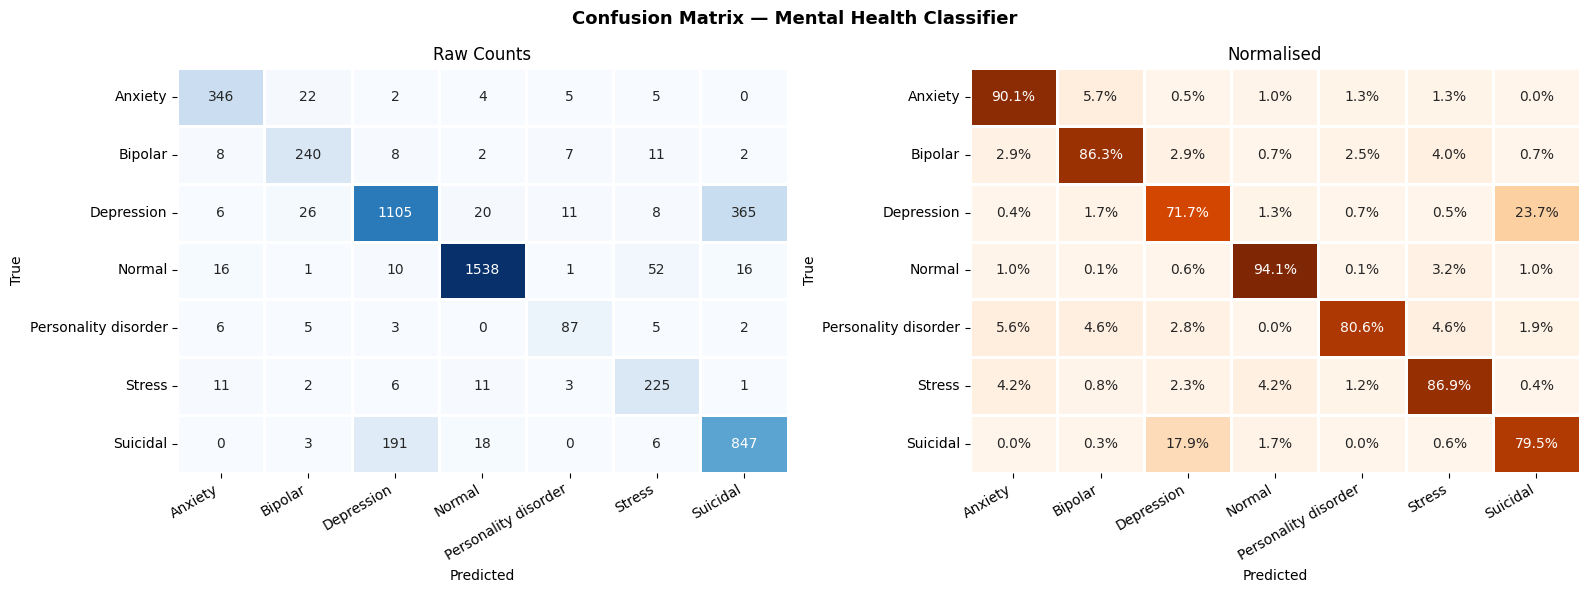

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()
print('✅ Best checkpoint loaded\n')

# Full validation pass
v_preds, v_labels, v_probs = [], [], []
with torch.no_grad():
    for batch in val_loader:
        out = model(
            input_ids=batch['input_ids'].to(DEVICE),
            attention_mask=batch['attention_mask'].to(DEVICE)
        )
        probs = torch.softmax(out.logits, dim=1).cpu().numpy()
        v_probs.extend(probs)
        v_preds.extend(np.argmax(probs, axis=1))
        v_labels.extend(batch['labels'].numpy())

class_names = [ID2LABEL[i] for i in range(NUM_LABELS)]

print('════════════════════════════════════════')
print(f'  Accuracy    : {accuracy_score(v_labels,v_preds):.4f}')
print(f'  Macro F1    : {f1_score(v_labels,v_preds,average="macro"):.4f}')
print(f'  Weighted F1 : {f1_score(v_labels,v_preds,average="weighted"):.4f}')
print('════════════════════════════════════════\n')
print(classification_report(v_labels, v_preds, target_names=class_names))

# Confusion matrix
cm      = confusion_matrix(v_labels, v_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:,np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix — Mental Health Classifier',
             fontsize=13, fontweight='bold')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='white', cbar=False)
axes[0].set_title('Raw Counts')
axes[0].set_xticklabels(class_names, rotation=30, ha='right')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Oranges', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='white', cbar=False)
axes[1].set_title('Normalised')
axes[1].set_xticklabels(class_names, rotation=30, ha='right')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def predict_mental_health(texts, model, tokenizer,
                           device, max_len=128, top_k=2):
    model.eval()
    results = []
    for text in texts:
        enc = tokenizer(
            clean_text(text), max_length=max_len,
            padding='max_length', truncation=True,
            return_tensors='pt'
        )
        with torch.no_grad():
            logits = model(
                input_ids=enc['input_ids'].to(device),
                attention_mask=enc['attention_mask'].to(device)
            ).logits
        probs   = torch.softmax(logits, dim=1)[0].cpu().numpy()
        top_ids = probs.argsort()[::-1][:top_k]
        results.append({
            'text'       : text,
            'prediction' : ID2LABEL[top_ids[0]],
            'confidence' : round(float(probs[top_ids[0]]), 4),
            'top_k'      : [(ID2LABEL[i], round(float(probs[i]),4))
                            for i in top_ids]
        })
    return results

# Test sentences
tests = [
    'I feel empty and nothing brings me joy anymore.',
    'Had a wonderful day with family, feeling grateful.',
    'I keep thinking about ending it all, there is no way out.',
    'My heart races and I cannot stop worrying about everything.',
    'My moods shift so fast, one day amazing, next day rock bottom.',
    'Work pressure is unbearable, I cannot sleep at all.',
]

results = predict_mental_health(tests, model, tokenizer, DEVICE)
print(f'{"Text":<48} {"Prediction":<22} Conf')
print('-'*85)
for r in results:
    print(f'{r["text"][:46]:<48} {r["prediction"]:<22} {r["confidence"]:.4f}')
    print(f'  top-2: {r["top_k"]}\n')

Text                                             Prediction             Conf
-------------------------------------------------------------------------------------
I feel empty and nothing brings me joy anymore   Depression             0.7163
  top-2: [('Depression', 0.7163), ('Suicidal', 0.2803)]

Had a wonderful day with family, feeling grate   Normal                 0.9937
  top-2: [('Normal', 0.9937), ('Suicidal', 0.0018)]

I keep thinking about ending it all, there is    Suicidal               0.9049
  top-2: [('Suicidal', 0.9049), ('Depression', 0.0926)]

My heart races and I cannot stop worrying abou   Anxiety                0.9442
  top-2: [('Anxiety', 0.9442), ('Depression', 0.0273)]

My moods shift so fast, one day amazing, next    Bipolar                0.9817
  top-2: [('Bipolar', 0.9817), ('Depression', 0.0114)]

Work pressure is unbearable, I cannot sleep at   Stress                 0.9661
  top-2: [('Stress', 0.9661), ('Depression', 0.0115)]



In [ ]:
from google.colab import files as colab_files

SAVE_DIR = 'roberta_mental_health_model'
os.makedirs(SAVE_DIR, exist_ok=True)

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Save label mappings — needed for inference
json.dump({str(k):v for k,v in ID2LABEL.items()},
          open(f'{SAVE_DIR}/id2label.json','w'))
json.dump({k:int(v) for k,v in LABEL2ID.items()},
          open(f'{SAVE_DIR}/label2id.json','w'))

# Backup full model to Drive
drive_final = f'{DRIVE_DIR}/final_model'
shutil.copytree(SAVE_DIR, drive_final, dirs_exist_ok=True)
print(f'✅ Full model saved to Drive: {drive_final}')

# Zip and download to PC
shutil.make_archive('roberta_mental_health_model', 'zip', SAVE_DIR)
colab_files.download('roberta_mental_health_model.zip')
print('📥 Download started')

✅ Full model saved to Drive: /content/drive/MyDrive/mental_health_model/final_model


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Download started


In [ ]:
from google.colab import drive, files
import os, json, shutil

# Mount Drive if not already mounted
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/mental_health_model'

# ── List what's available on Drive ────────────────────────────
print('Files on Drive:')
for f in sorted(os.listdir(DRIVE_DIR)):
    size = os.path.getsize(f'{DRIVE_DIR}/{f}') / 1e6 \
           if os.path.isfile(f'{DRIVE_DIR}/{f}') else 0
    print(f'  {f}  ({size:.0f} MB)' if size else f'  {f}/')

# ── Copy .pt to Colab disk ─────────────────────────────────────
pt_src = f'{DRIVE_DIR}/best_mental_health_model.pt'
pt_dst = 'best_mental_health_model.pt'

if os.path.exists(pt_src):
    shutil.copy(pt_src, pt_dst)
    size = os.path.getsize(pt_dst) / 1e6
    print(f'\n✅ Copied .pt file ({size:.0f} MB) to Colab disk')
else:
    print('\n❌ best_mental_health_model.pt not found on Drive')
    print('   Check the filenames printed above')

# ── Save label maps as standalone JSON files ───────────────────
# These are needed alongside the .pt for inference
json.dump(
    {str(k): v for k, v in ID2LABEL.items()},
    open('id2label.json', 'w')
)
json.dump(
    {k: int(v) for k, v in LABEL2ID.items()},
    open('label2id.json', 'w')
)
print('✅ id2label.json and label2id.json saved')

# ── Download all three to your PC ─────────────────────────────
print('\n📥 Starting downloads...')
files.download('best_mental_health_model.pt')
files.download('id2label.json')
files.download('label2id.json')
print('📥 3 files downloading — check your browser')

Mounted at /content/drive
Files on Drive:
  best_mental_health_model.pt  (499 MB)
  final_model/

✅ Copied .pt file (499 MB) to Colab disk


NameError: name 'ID2LABEL' is not defined